<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd

## Step 2. Import the dataset

In [3]:
df = pd.read_csv("50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [10]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

## Step 3 . Check the State Column

In [12]:
df["State"].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [98]:
x = df.drop("Profit",axis=1)
#x = df.iloc[::,:4:]
#y = df.iloc[::,4::]
y = df["Profit"]
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [102]:
#from sklearn.preprocessing import OneHotEncoder
x1 = pd.get_dummies(x,columns=['State'],drop_first=True)
x1.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False


In [104]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [107]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [110]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42)


In [112]:
x_test.shape

(10, 5)

## Step 8  Import LinearRegression model from linear_model family 

In [115]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()



In [117]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 9  Fit the data

In [120]:
y_train

12    141585.52
4     166187.94
37     89949.14
8     152211.77
3     182901.99
6     156122.51
41     77798.83
46     49490.75
47     42559.73
15    129917.04
9     149759.96
16    126992.93
24    108552.04
34     96712.80
31     97483.56
0     192261.83
44     65200.33
27    105008.31
33     96778.92
5     156991.12
29    101004.64
11    144259.40
36     90708.19
1     191792.06
21    111313.02
2     191050.39
43     69758.98
35     96479.51
23    108733.99
40     78239.91
10    146121.95
22    110352.25
18    124266.90
49     14681.40
20    118474.03
7     155752.60
42     71498.49
14    132602.65
28    103282.38
38     81229.06
Name: Profit, dtype: float64

In [122]:
model.fit(x_train,y_train)

LinearRegression()

## Step 10  Predict the data

In [124]:
y_pred = model.predict(X_test)
y_pred


array([126362.87908255,  84608.45383634,  99677.49425147,  46357.46068582,
       128750.48288504,  50912.4174188 , 109741.35032702, 100643.24281647,
        97599.27574594, 113097.42524432])

## Step 11  Display Result

In [22]:
# y_test and y_predict

In [126]:
import matplotlib.pyplot

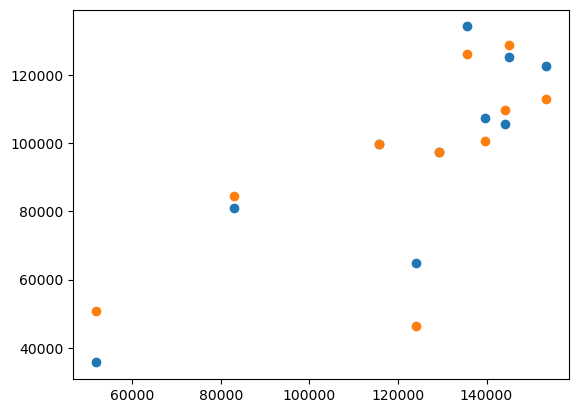

In [150]:
plt.scatter(x_test['Administration'],y_test)
plt.scatter(x_test['Administration'],y_pred)

In [130]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred
})

comparison


,Actual Profit,Predicted Profit
0,134307.35,126362.879083
1,81005.76,84608.453836
2,99937.59,99677.494251
3,64926.08,46357.460686
4,125370.37,128750.482885
5,35673.41,50912.417419
6,105733.54,109741.350327
7,107404.34,100643.242816
8,97427.84,97599.275746
9,122776.86,113097.425244


## RSS

In [135]:
import numpy as np

In [137]:
np.sum((y_test.values - y_pred) ** 2)

820103630.4430106

In [139]:
len(y_test)

10

In [142]:
from sklearn.metrics import mean_squared_error

In [144]:
mean_squared_error(y_test.values,y_pred) * len(y_pred)

820103630.4430106

In [147]:
len(y_pred)

10

## R Square

In [152]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8987266414328636

0.9522016331732872

## Now use Polynomial Regression on Position_Salaries dataset

In [156]:
df = pd.read_csv("Position_Salaries.csv")

In [158]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


Text(0, 0.5, 'Salary')

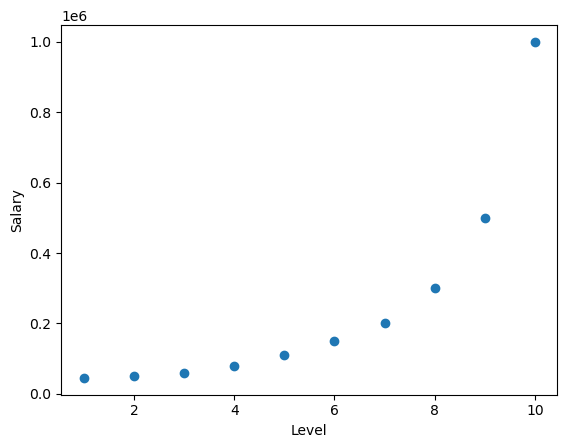

In [180]:
plt.scatter(df['Level'],df['Salary'])
plt.xlabel("Level")
plt.ylabel("Salary")